# RSO-80: Assess the Scheduler CSC configuration time after enabling

**Descripcion**

I was interested in evaluating the time from when the scheduler CSC is enabled, to when the scheduler CSC is configured.

 

The context for this is to evaluate the overall latency of the Rubin ToO system. We have advanced information from the LVK side, and 2/5 of the Rubin steps for observing. 

 

My thought would be to evaluate this over the entire commissioning period, OR over a period of time since we have deployed any improvements to minimize the configure time.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)
from astropy.time import Time

In [4]:
# Initialize an EFD client
efd_client = makeEfdClient()

In [5]:
# day_obs = 20250601
start_time = Time("2026-01-10T00:00:00Z", scale="utc")
end_time = Time("2026-01-15T23:30:00Z", scale="utc")

## ************************

In [6]:
# Disable
df_disable = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_disable",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [7]:
df_disable['timestamp'] = df_disable.index
df_disable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:51.755275+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,9c0ea436,326174075,1.768008e+09,1,2026-01-10 01:21:51.755275+00:00
2026-01-10 23:51:10.728102+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,9c0ea436,326174075,1.768089e+09,2,2026-01-10 23:51:10.728102+00:00
2026-01-11 00:32:34.236172+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,9c0ea436,326174075,1.768092e+09,1,2026-01-11 00:32:34.236172+00:00
2026-01-11 01:36:26.601585+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,9c0ea436,326174075,1.768095e+09,2,2026-01-11 01:36:26.601585+00:00
2026-01-11 14:09:01.513233+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,9c0ea436,326174075,1.768141e+09,2,2026-01-11 14:09:01.513233+00:00
2026-01-12 00:07:05.932101+00:00,1.768176e+09,Script:214416,1.768176e+09,150391,0,9c0ea436,326174075,1.768176e+09,2,2026-01-12 00:07:05.932101+00:00
2026-01-12 07:03:19.758704+00:00,1.768201e+09,Script:112758,1.768201e+09,376781,0,9c0ea436,326174075,1.768201e+09,1,2026-01-12 07:03:19.758704+00:00
2026-01-12 23:51:16.872159+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,9c0ea436,326174075,1.768262e+09,2,2026-01-12 23:51:16.872159+00:00
2026-01-13 04:39:10.763242+00:00,1.768279e+09,Script:112987,1.768279e+09,535953,0,9c0ea436,326174075,1.768279e+09,1,2026-01-13 04:39:10.763242+00:00
2026-01-13 23:51:24.910814+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,9c0ea436,326174075,1.768348e+09,2,2026-01-13 23:51:24.910814+00:00


In [8]:
# Enable
df_enable = getEfdData(
            client=efd_client,
            topic="lsst.sal.Scheduler.command_enable",
            columns=["*"],
            begin=start_time,
            end=end_time,
)

In [9]:
df_enable['timestamp'] = df_enable.index
df_enable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:27:23.198661+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,4123e633,476961495,1.768008e+09,1,2026-01-10 01:27:23.198661+00:00
2026-01-10 23:51:45.790239+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,4123e633,476961495,1.768089e+09,2,2026-01-10 23:51:45.790239+00:00
2026-01-11 00:37:43.405530+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,4123e633,476961495,1.768092e+09,1,2026-01-11 00:37:43.405530+00:00
2026-01-11 01:37:04.950707+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,4123e633,476961495,1.768095e+09,2,2026-01-11 01:37:04.950707+00:00
2026-01-11 14:09:38.495453+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,4123e633,476961495,1.768141e+09,2,2026-01-11 14:09:38.495453+00:00
2026-01-12 00:07:57.981250+00:00,1.768176e+09,Script:214416,1.768177e+09,150391,0,4123e633,476961495,1.768177e+09,2,2026-01-12 00:07:57.981250+00:00
2026-01-12 07:09:15.012064+00:00,1.768202e+09,Script:112758,1.768202e+09,376781,0,4123e633,476961495,1.768202e+09,1,2026-01-12 07:09:15.012064+00:00
2026-01-12 23:51:54.150495+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,4123e633,476961495,1.768262e+09,2,2026-01-12 23:51:54.150495+00:00
2026-01-13 04:44:51.623314+00:00,1.768279e+09,Script:112987,1.768280e+09,535953,0,4123e633,476961495,1.768280e+09,1,2026-01-13 04:44:51.623314+00:00
2026-01-13 23:52:00.632737+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,4123e633,476961495,1.768348e+09,2,2026-01-13 23:52:00.632737+00:00


In [10]:
# Exit Control
df_exitControl = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_exitControl",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [11]:
df_exitControl['timestamp'] = df_exitControl.index
df_exitControl

,timestamp


In [12]:
# setLogLevel
df_setLogLevel = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_setLogLevel",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [13]:
df_setLogLevel['timestamp'] = df_setLogLevel.index
df_setLogLevel

,timestamp


In [14]:
# standby
df_standby = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_standby",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [15]:
df_standby['timestamp'] = df_standby.index
df_standby

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:57.334168+00:00,1.768008e+09,Script:111453,1.768008e+09,3400085,0,cd1b64f4,1616103400,1.768008e+09,1,2026-01-10 01:21:57.334168+00:00
2026-01-10 23:51:16.307530+00:00,1.768089e+09,Script:213822,1.768089e+09,3988392,0,cd1b64f4,1616103400,1.768089e+09,2,2026-01-10 23:51:16.307530+00:00
2026-01-11 00:32:39.820630+00:00,1.768092e+09,Script:112073,1.768092e+09,3946145,0,cd1b64f4,1616103400,1.768092e+09,1,2026-01-11 00:32:39.820630+00:00
2026-01-11 01:36:32.176299+00:00,1.768095e+09,Script:213884,1.768095e+09,4023197,0,cd1b64f4,1616103400,1.768095e+09,2,2026-01-11 01:36:32.176299+00:00
2026-01-11 14:09:07.086490+00:00,1.768141e+09,Script:214385,1.768141e+09,141507,0,cd1b64f4,1616103400,1.768141e+09,2,2026-01-11 14:09:07.086490+00:00
2026-01-12 00:07:11.494748+00:00,1.768176e+09,Script:214416,1.768176e+09,150391,0,cd1b64f4,1616103400,1.768176e+09,2,2026-01-12 00:07:11.494748+00:00
2026-01-12 07:03:25.306961+00:00,1.768201e+09,Script:112758,1.768201e+09,376781,0,cd1b64f4,1616103400,1.768201e+09,1,2026-01-12 07:03:25.306961+00:00
2026-01-12 23:51:22.475054+00:00,1.768262e+09,Script:215018,1.768262e+09,504670,0,cd1b64f4,1616103400,1.768262e+09,2,2026-01-12 23:51:22.475054+00:00
2026-01-13 04:39:16.316808+00:00,1.768279e+09,Script:112987,1.768279e+09,535953,0,cd1b64f4,1616103400,1.768279e+09,1,2026-01-13 04:39:16.316808+00:00
2026-01-13 23:51:30.485094+00:00,1.768348e+09,Script:215427,1.768348e+09,744080,0,cd1b64f4,1616103400,1.768348e+09,2,2026-01-13 23:51:30.485094+00:00


In [16]:
# Start
df_start = getEfdData(
           client=efd_client,
           topic="lsst.sal.Scheduler.command_start",
           columns=["*"],
           begin=start_time,
           end=end_time,
)

In [17]:
df_start['timestamp'] = df_start.index
df_start

,configurationOverride,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2026-01-10 01:21:58.386950+00:00,fbs_config_lsst_survey_block_419.yaml,1.768008e+09,Script:111453,1.768008e+09,3400085,0,52da5621,1851544648,1.768008e+09,1,2026-01-10 01:21:58.386950+00:00
2026-01-10 23:51:17.371641+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768089e+09,Script:213822,1.768089e+09,3988392,0,52da5621,1851544648,1.768089e+09,2,2026-01-10 23:51:17.371641+00:00
2026-01-11 00:32:40.893540+00:00,fbs_config_lsst_survey_block_419.yaml,1.768092e+09,Script:112073,1.768092e+09,3946145,0,52da5621,1851544648,1.768092e+09,1,2026-01-11 00:32:40.893540+00:00
2026-01-11 01:36:33.243459+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768095e+09,Script:213884,1.768095e+09,4023197,0,52da5621,1851544648,1.768095e+09,2,2026-01-11 01:36:33.243459+00:00
2026-01-11 14:09:08.158330+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768141e+09,Script:214385,1.768141e+09,141507,0,52da5621,1851544648,1.768141e+09,2,2026-01-11 14:09:08.158330+00:00
2026-01-12 00:07:12.551209+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768176e+09,Script:214416,1.768176e+09,150391,0,52da5621,1851544648,1.768176e+09,2,2026-01-12 00:07:12.551209+00:00
2026-01-12 07:03:26.375660+00:00,fbs_config_lsst_survey_block_419.yaml,1.768201e+09,Script:112758,1.768201e+09,376781,0,52da5621,1851544648,1.768201e+09,1,2026-01-12 07:03:26.375660+00:00
2026-01-12 23:51:23.522967+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768262e+09,Script:215018,1.768262e+09,504670,0,52da5621,1851544648,1.768262e+09,2,2026-01-12 23:51:23.522967+00:00
2026-01-13 04:39:17.389900+00:00,fbs_config_lsst_survey_block_419.yaml,1.768279e+09,Script:112987,1.768279e+09,535953,0,52da5621,1851544648,1.768279e+09,1,2026-01-13 04:39:17.389900+00:00
2026-01-13 23:51:31.544646+00:00,auxtel_fbs_spec_flex_survey.yaml,1.768348e+09,Script:215427,1.768348e+09,744080,0,52da5621,1851544648,1.768348e+09,2,2026-01-13 23:51:31.544646+00:00


## latencies

In [41]:
for df in [df_disable, df_enable, df_standby, df_start]:
    df['script_id'] = df['private_identity'].str.replace('Script:', '', regex=False).astype(int)

In [42]:
df_disable_lat = df_disable[['script_id', 'timestamp']]
df_enable_lat  = df_enable[['script_id', 'timestamp']]
df_standby_lat = df_standby[['script_id', 'timestamp']]
df_start_lat    = df_start[['script_id', 'timestamp']]

In [43]:
# Rename column of timestamp
df_disable_lat = df_disable_lat.rename(columns={'timestamp': 'ts_disable'})
df_enable_lat  = df_enable_lat.rename(columns={'timestamp': 'ts_enable'})
df_standby_lat = df_standby_lat.rename(columns={'timestamp': 'ts_standby'})
df_start_lat    = df_start_lat.rename(columns={'timestamp': 'ts_start'})

In [44]:
# Partial Latencies 
df_latencies = (
    df_disable_lat
    .merge(df_enable_lat,  on='script_id', how='inner')
    .merge(df_standby_lat, on='script_id', how='inner')
    .merge(df_start_lat,   on='script_id', how='inner')
)

In [45]:
df_latencies['lat_disable_enable_s'] = (
    df_latencias['ts_enable'] - df_latencias['ts_disable']
).dt.total_seconds() # * 1000

In [46]:
df_latencies['lat_enable_standby_s'] = (
    df_latencias['ts_standby'] - df_latencias['ts_enable']
).dt.total_seconds() # * 1000

In [51]:
df_latencies['lat_standby_start_s'] = (
    df_latencias['ts_start'] - df_latencias['ts_standby']
).dt.total_seconds()

In [47]:
df_latencies['lat_total_s'] = (
    df_latencias['ts_start'] - df_latencias['ts_disable']
).dt.total_seconds() # * 1000

In [52]:
df_latencies

,script_id,ts_disable,ts_enable,ts_standby,ts_start,lat_disable_enable_s,lat_enable_standby_s,lat_total_s,lat_standby_start_s
0,111453,2026-01-10 01:21:51.755275+00:00,2026-01-10 01:27:23.198661+00:00,2026-01-10 01:21:57.334168+00:00,2026-01-10 01:21:58.386950+00:00,331.443386,-325.864493,6.631675,1.052782
1,213822,2026-01-10 23:51:10.728102+00:00,2026-01-10 23:51:45.790239+00:00,2026-01-10 23:51:16.307530+00:00,2026-01-10 23:51:17.371641+00:00,35.062137,-29.482709,6.643539,1.064111
2,112073,2026-01-11 00:32:34.236172+00:00,2026-01-11 00:37:43.405530+00:00,2026-01-11 00:32:39.820630+00:00,2026-01-11 00:32:40.893540+00:00,309.169358,-303.584900,6.657368,1.072910
3,213884,2026-01-11 01:36:26.601585+00:00,2026-01-11 01:37:04.950707+00:00,2026-01-11 01:36:32.176299+00:00,2026-01-11 01:36:33.243459+00:00,38.349122,-32.774408,6.641874,1.067160
4,214385,2026-01-11 14:09:01.513233+00:00,2026-01-11 14:09:38.495453+00:00,2026-01-11 14:09:07.086490+00:00,2026-01-11 14:09:08.158330+00:00,36.982220,-31.408963,6.645097,1.071840
5,214416,2026-01-12 00:07:05.932101+00:00,2026-01-12 00:07:57.981250+00:00,2026-01-12 00:07:11.494748+00:00,2026-01-12 00:07:12.551209+00:00,52.049149,-46.486502,6.619108,1.056461
6,112758,2026-01-12 07:03:19.758704+00:00,2026-01-12 07:09:15.012064+00:00,2026-01-12 07:03:25.306961+00:00,2026-01-12 07:03:26.375660+00:00,355.253360,-349.705103,6.616956,1.068699
7,215018,2026-01-12 23:51:16.872159+00:00,2026-01-12 23:51:54.150495+00:00,2026-01-12 23:51:22.475054+00:00,2026-01-12 23:51:23.522967+00:00,37.278336,-31.675441,6.650808,1.047913
8,112987,2026-01-13 04:39:10.763242+00:00,2026-01-13 04:44:51.623314+00:00,2026-01-13 04:39:16.316808+00:00,2026-01-13 04:39:17.389900+00:00,340.860072,-335.306506,6.626658,1.073092
9,215427,2026-01-13 23:51:24.910814+00:00,2026-01-13 23:52:00.632737+00:00,2026-01-13 23:51:30.485094+00:00,2026-01-13 23:51:31.544646+00:00,35.721923,-30.147643,6.633832,1.059552


### Plots

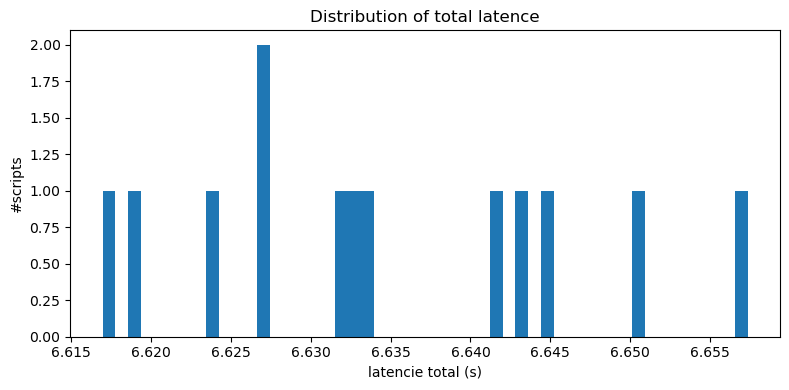

In [57]:
plt.figure(figsize=(8, 4))
plt.hist(df_latencies['lat_total_s'], bins=50)
plt.xlabel('latencie total (s)')
plt.ylabel('# Scripts')
plt.title('Distribution of total latence')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7535/190149007.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


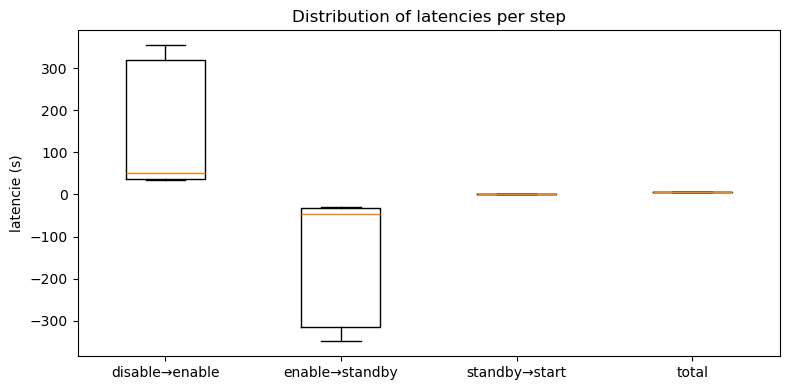

In [58]:
plt.figure(figsize=(8, 4))

plt.boxplot([
    df_latencies['lat_disable_enable_s'],
    df_latencies['lat_enable_standby_s'],
    df_latencies['lat_standby_start_s'],
    df_latencies['lat_total_s'],
], labels=[
    'disable→enable',
    'enable→standby',
    'standby→start',
    'total'
])

plt.ylabel('latencie (s)')
plt.title('Distribution of latencies per step')
plt.tight_layout()
plt.show()

In [61]:
df_latencies['lat_total_s'].describe(percentiles=[0.5, 0.95, 0.99])


count    13.000000
mean      6.634653
std       0.012345
min       6.616956
50%       6.632844
95%       6.653432
99%       6.656581
max       6.657368
Name: lat_total_s, dtype: float64